# Money as a Medium of Exchange with Deep Reinforcement Learning

## AlphaGo-Style AI for the Kiyotaki-Wright Model

This notebook implements **deep reinforcement learning** algorithms inspired by AlphaGo for the Kiyotaki-Wright exchange economy, allowing direct comparison with the Holland classifier system results from Marimon, McGrattan, and Sargent (1990).

### Overview

While Marimon, McGrattan, and Sargent used **Holland's classifier systems** (1990), we replace them with modern **deep reinforcement learning** techniques inspired by AlphaGo:

1. **Deep Q-Networks (DQN)**: Neural networks that learn to approximate optimal Q-values
2. **Experience Replay**: Store and reuse past experiences for more stable learning
3. **Target Networks**: Separate target networks for stable Q-value estimation
4. **ε-Greedy Exploration**: Balance exploration and exploitation

### Key Research Questions

1. Do **deep RL agents** converge to the same Nash equilibria as Holland classifier agents?
2. Does the **fundamental equilibrium** still emerge (goods with low storage cost as money)?
3. How do **convergence dynamics** differ between Holland classifiers and deep RL?
4. Can deep RL handle the **credit assignment problem** in multi-agent exchange economies?

### The AlphaGo Connection

AlphaGo combined:
- **Deep neural networks** for value and policy estimation
- **Monte Carlo Tree Search (MCTS)** for planning
- **Self-play** for training

Our implementation adapts these principles:
- **Deep Q-Networks** replace the value network
- **Experience replay** provides the training data
- **Agent interactions** replace self-play
- We add a **policy network** option for direct policy learning

## 1. Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import List, Tuple, Dict, Optional, Deque
from collections import deque
import warnings
warnings.filterwarnings('ignore')

# For reproducibility
np.random.seed(42)

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print("Setup complete.")

Setup complete.


## 2. Economy Configuration

We use the same Kiyotaki-Wright economy structure as the original paper.

In [2]:
@dataclass
class EconomyConfig:
    """
    Configuration for a Kiyotaki-Wright economy with deep RL agents.
    
    Parameters match the original paper for direct comparison.
    """
    name: str = "Economy A1 (Deep RL)"
    n_types: int = 3
    n_agents_per_type: int = 50
    produces: np.ndarray = field(default_factory=lambda: np.array([1, 2, 0]))  # 0-indexed
    storage_costs: np.ndarray = field(default_factory=lambda: np.array([0.1, 1.0, 20.0]))
    utility: np.ndarray = field(default_factory=lambda: np.array([100.0, 100.0, 100.0]))
    
    # Deep RL hyperparameters
    hidden_dim: int = 64
    learning_rate: float = 0.001
    gamma: float = 0.95  # Discount factor
    epsilon_start: float = 1.0
    epsilon_end: float = 0.05
    epsilon_decay: float = 0.9995
    replay_buffer_size: int = 10000
    batch_size: int = 64
    target_update_freq: int = 100
    
    @property
    def n_agents(self):
        return self.n_types * self.n_agents_per_type
    
    @property 
    def n_goods(self):
        return self.n_types

print("EconomyConfig class defined.")

EconomyConfig class defined.


## 3. Neural Network Architecture

We implement a simple but effective MLP architecture for Q-value estimation.

In [3]:
class SimpleNN:
    """
    Simple feedforward neural network for Q-value estimation.
    
    Uses manual backpropagation (no external deep learning libraries)
    for self-contained implementation.
    """
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int, lr: float = 0.001):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.lr = lr
        
        # Initialize weights (Xavier initialization)
        self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2.0 / input_dim)
        self.b1 = np.zeros(hidden_dim)
        self.W2 = np.random.randn(hidden_dim, hidden_dim) * np.sqrt(2.0 / hidden_dim)
        self.b2 = np.zeros(hidden_dim)
        self.W3 = np.random.randn(hidden_dim, output_dim) * np.sqrt(2.0 / hidden_dim)
        self.b3 = np.zeros(output_dim)
        
        # Momentum terms for Adam-like optimizer
        self.m_W1, self.v_W1 = np.zeros_like(self.W1), np.zeros_like(self.W1)
        self.m_b1, self.v_b1 = np.zeros_like(self.b1), np.zeros_like(self.b1)
        self.m_W2, self.v_W2 = np.zeros_like(self.W2), np.zeros_like(self.W2)
        self.m_b2, self.v_b2 = np.zeros_like(self.b2), np.zeros_like(self.b2)
        self.m_W3, self.v_W3 = np.zeros_like(self.W3), np.zeros_like(self.W3)
        self.m_b3, self.v_b3 = np.zeros_like(self.b3), np.zeros_like(self.b3)
        self.t = 0
        
        self.beta1 = 0.9
        self.beta2 = 0.999
        self.epsilon = 1e-8
    
    def relu(self, x):
        return np.maximum(0, x)
    
    def relu_derivative(self, x):
        return (x > 0).astype(float)
    
    def forward(self, x):
        """Forward pass. x can be a batch."""
        self.x = x
        self.z1 = x @ self.W1 + self.b1
        self.a1 = self.relu(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.relu(self.z2)
        self.z3 = self.a2 @ self.W3 + self.b3
        return self.z3  # Linear output for Q-values
    
    def backward(self, q_target):
        """
        Backward pass with gradient descent.
        q_target: target Q-values (same shape as output)
        """
        m = self.x.shape[0]  # Batch size
        
        # Output layer gradient
        dz3 = self.z3 - q_target
        dW3 = (self.a2.T @ dz3) / m
        db3 = np.mean(dz3, axis=0)
        
        # Hidden layer 2 gradient
        da2 = dz3 @ self.W3.T
        dz2 = da2 * self.relu_derivative(self.z2)
        dW2 = (self.a1.T @ dz2) / m
        db2 = np.mean(dz2, axis=0)
        
        # Hidden layer 1 gradient
        da1 = dz2 @ self.W2.T
        dz1 = da1 * self.relu_derivative(self.z1)
        dW1 = (self.x.T @ dz1) / m
        db1 = np.mean(dz1, axis=0)
        
        # Adam optimizer update
        self.t += 1
        self._adam_update('W1', dW1, self.m_W1, self.v_W1)
        self._adam_update('b1', db1, self.m_b1, self.v_b1)
        self._adam_update('W2', dW2, self.m_W2, self.v_W2)
        self._adam_update('b2', db2, self.m_b2, self.v_b2)
        self._adam_update('W3', dW3, self.m_W3, self.v_W3)
        self._adam_update('b3', db3, self.m_b3, self.v_b3)
    
    def _adam_update(self, param_name, grad, m, v):
        """Adam optimizer update for a parameter."""
        m[:] = self.beta1 * m + (1 - self.beta1) * grad
        v[:] = self.beta2 * v + (1 - self.beta2) * (grad ** 2)
        
        m_hat = m / (1 - self.beta1 ** self.t)
        v_hat = v / (1 - self.beta2 ** self.t)
        
        param = getattr(self, param_name)
        param -= self.lr * m_hat / (np.sqrt(v_hat) + self.epsilon)
    
    def predict(self, x):
        """Predict without storing intermediate values."""
        z1 = x @ self.W1 + self.b1
        a1 = self.relu(z1)
        z2 = a1 @ self.W2 + self.b2
        a2 = self.relu(z2)
        z3 = a2 @ self.W3 + self.b3
        return z3
    
    def copy_from(self, other_nn):
        """Copy weights from another network (for target network updates)."""
        self.W1 = other_nn.W1.copy()
        self.b1 = other_nn.b1.copy()
        self.W2 = other_nn.W2.copy()
        self.b2 = other_nn.b2.copy()
        self.W3 = other_nn.W3.copy()
        self.b3 = other_nn.b3.copy()

print("Neural network class defined.")

Neural network class defined.


## 4. Experience Replay Buffer

Experience replay is a key innovation from DQN that stabilizes training by:
1. Breaking temporal correlations in the data
2. Reusing experiences multiple times
3. Smoothing out learning updates

In [4]:
class ReplayBuffer:
    """
    Experience replay buffer for storing and sampling transitions.
    
    Each transition is (state, action, reward, next_state, done).
    """
    def __init__(self, capacity: int):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state, action, reward, next_state, done):
        """Add a transition to the buffer."""
        self.buffer.append((state, action, reward, next_state, done))
    
    def sample(self, batch_size: int):
        """Sample a random batch of transitions."""
        indices = np.random.choice(len(self.buffer), batch_size, replace=False)
        batch = [self.buffer[i] for i in indices]
        
        states = np.array([t[0] for t in batch])
        actions = np.array([t[1] for t in batch])
        rewards = np.array([t[2] for t in batch])
        next_states = np.array([t[3] for t in batch])
        dones = np.array([t[4] for t in batch])
        
        return states, actions, rewards, next_states, dones
    
    def __len__(self):
        return len(self.buffer)

print("Replay buffer class defined.")

Replay buffer class defined.


## 5. Deep Q-Learning Agent

Each agent learns two separate policies:
1. **Trade policy**: Q(own_good, partner_good) → trade/don't trade
2. **Consume policy**: Q(own_good) → consume/don't consume

This mirrors the Holland classifier system structure.

In [5]:
class DQNAgent:
    """
    Deep Q-Network agent for the Kiyotaki-Wright model.
    
    Maintains separate networks for trade and consume decisions,
    following the structure of the Holland classifier system.
    """
    def __init__(self, agent_type: int, config: EconomyConfig):
        self.agent_type = agent_type
        self.config = config
        
        # State dimensions
        self.trade_state_dim = 2 * config.n_goods  # One-hot: own good + partner good
        self.consume_state_dim = config.n_goods    # One-hot: own good
        self.n_actions = 2  # Binary: 0 = don't act, 1 = act
        
        # Trade Q-networks (policy + target)
        self.trade_qnet = SimpleNN(self.trade_state_dim, config.hidden_dim, 
                                    self.n_actions, config.learning_rate)
        self.trade_target_qnet = SimpleNN(self.trade_state_dim, config.hidden_dim, 
                                          self.n_actions, config.learning_rate)
        self.trade_target_qnet.copy_from(self.trade_qnet)
        
        # Consume Q-networks (policy + target)
        self.consume_qnet = SimpleNN(self.consume_state_dim, config.hidden_dim,
                                     self.n_actions, config.learning_rate)
        self.consume_target_qnet = SimpleNN(self.consume_state_dim, config.hidden_dim,
                                            self.n_actions, config.learning_rate)
        self.consume_target_qnet.copy_from(self.consume_qnet)
        
        # Replay buffers
        self.trade_replay = ReplayBuffer(config.replay_buffer_size)
        self.consume_replay = ReplayBuffer(config.replay_buffer_size)
        
        # Exploration parameters
        self.epsilon = config.epsilon_start
        self.epsilon_end = config.epsilon_end
        self.epsilon_decay = config.epsilon_decay
        
        # Training counters
        self.updates = 0
    
    def _one_hot_trade_state(self, own_good: int, partner_good: int) -> np.ndarray:
        """Encode trade state as one-hot vector."""
        state = np.zeros(self.trade_state_dim)
        state[own_good] = 1
        state[self.config.n_goods + partner_good] = 1
        return state
    
    def _one_hot_consume_state(self, own_good: int) -> np.ndarray:
        """Encode consume state as one-hot vector."""
        state = np.zeros(self.consume_state_dim)
        state[own_good] = 1
        return state
    
    def get_trade_action(self, own_good: int, partner_good: int) -> int:
        """Select trade action using ε-greedy policy."""
        state = self._one_hot_trade_state(own_good, partner_good)
        
        if np.random.rand() < self.epsilon:
            return np.random.randint(0, 2)
        else:
            q_values = self.trade_qnet.predict(state.reshape(1, -1))[0]
            return np.argmax(q_values)
    
    def get_consume_action(self, own_good: int) -> int:
        """Select consume action using ε-greedy policy."""
        state = self._one_hot_consume_state(own_good)
        
        if np.random.rand() < self.epsilon:
            return np.random.randint(0, 2)
        else:
            q_values = self.consume_qnet.predict(state.reshape(1, -1))[0]
            return np.argmax(q_values)
    
    def store_trade_experience(self, own_good: int, partner_good: int, 
                               action: int, reward: float,
                               next_own_good: int, next_partner_good: int):
        """Store a trade experience in the replay buffer."""
        state = self._one_hot_trade_state(own_good, partner_good)
        # Next state maintains trade state structure with post-trade goods
        next_state = self._one_hot_trade_state(next_own_good, next_partner_good)
        # Trade decision is terminal within this interaction
        self.trade_replay.push(state, action, reward, next_state, True)
    
    def store_consume_experience(self, own_good: int, action: int, 
                                 reward: float, next_own_good: int):
        """Store a consume experience in the replay buffer."""
        state = self._one_hot_consume_state(own_good)
        next_state = self._one_hot_consume_state(next_own_good)
        self.consume_replay.push(state, action, reward, next_state, True)  # Episode ends
    
    def train_step(self):
        """
        Perform one training step on both trade and consume networks.
        
        Implements the DQN update:
        Q(s,a) ← Q(s,a) + α[r + γ max_a' Q_target(s',a') - Q(s,a)]
        """
        batch_size = self.config.batch_size
        
        # Train trade network
        if len(self.trade_replay) >= batch_size:
            states, actions, rewards, next_states, dones = self.trade_replay.sample(batch_size)
            
            # Current Q-values
            q_values = self.trade_qnet.forward(states)
            
            # Target Q-values using target network
            next_q_values = self.trade_target_qnet.predict(next_states)
            max_next_q = np.max(next_q_values, axis=1)
            
            # Compute targets
            q_targets = q_values.copy()
            for i in range(batch_size):
                target = rewards[i] + self.config.gamma * max_next_q[i] * (1 - dones[i])
                q_targets[i, actions[i]] = target
            
            # Backprop
            self.trade_qnet.backward(q_targets)
        
        # Train consume network
        if len(self.consume_replay) >= batch_size:
            states, actions, rewards, next_states, dones = self.consume_replay.sample(batch_size)
            
            # Current Q-values
            q_values = self.consume_qnet.forward(states)
            
            # Target Q-values using target network
            next_q_values = self.consume_target_qnet.predict(next_states)
            max_next_q = np.max(next_q_values, axis=1)
            
            # Compute targets
            q_targets = q_values.copy()
            for i in range(batch_size):
                target = rewards[i] + self.config.gamma * max_next_q[i] * (1 - dones[i])
                q_targets[i, actions[i]] = target
            
            # Backprop
            self.consume_qnet.backward(q_targets)
        
        # Update target networks periodically
        self.updates += 1
        if self.updates % self.config.target_update_freq == 0:
            self.trade_target_qnet.copy_from(self.trade_qnet)
            self.consume_target_qnet.copy_from(self.consume_qnet)
        
        # Decay epsilon
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

print("DQN agent class defined.")

DQN agent class defined.


## 6. Simulation Engine

The simulation maintains the same matching and trading structure as the original paper,
but replaces classifier auction with deep Q-learning.

In [6]:
class KiyotakiWrightDQN:
    """
    Kiyotaki-Wright economy simulation with DQN agents.
    
    Maintains the same economy structure but uses deep RL for learning.
    """
    def __init__(self, config: EconomyConfig, seed: int = None):
        self.config = config
        if seed is not None:
            np.random.seed(seed)
        
        # Create DQN agent types (one per agent type, shared across agents of same type)
        self.agents = [DQNAgent(i, config) for i in range(config.n_types)]
        
        # Initialize holdings: each agent starts with a random good
        self.holdings = np.random.randint(0, config.n_goods, size=config.n_agents)
        
        # Map agent index to type
        self.agent_types = np.repeat(np.arange(config.n_types), config.n_agents_per_type)
        
        # Statistics tracking
        self.history = {
            'holdings_dist': [],
            'trade_rates': [],
            'consumption_rates': [],
            'epsilon': []  # Track exploration rate
        }
    
    def run(self, n_periods: int, record_every: int = 1, verbose: bool = True):
        """Run the simulation for n_periods."""
        config = self.config
        
        for t in range(1, n_periods + 1):
            trades_this_period = 0
            consumptions_this_period = 0
            
            # Random matching
            perm = np.random.permutation(config.n_agents)
            n_pairs = config.n_agents // 2
            
            for p in range(n_pairs):
                a1, a2 = perm[2*p], perm[2*p + 1]
                type1, type2 = self.agent_types[a1], self.agent_types[a2]
                good1, good2 = self.holdings[a1], self.holdings[a2]
                
                agent1, agent2 = self.agents[type1], self.agents[type2]
                
                # --- Trade Phase ---
                action1 = agent1.get_trade_action(good1, good2)
                action2 = agent2.get_trade_action(good2, good1)
                
                trade_happens = (action1 == 1) and (action2 == 1)
                
                # Immediate reward from trade decision (zero for now, updated after consume)
                trade_reward1, trade_reward2 = 0.0, 0.0
                
                if trade_happens:
                    self.holdings[a1], self.holdings[a2] = good2, good1
                    trades_this_period += 1
                
                post_good1, post_good2 = self.holdings[a1], self.holdings[a2]
                
                # --- Consume Phase ---
                cons_action1 = agent1.get_consume_action(post_good1)
                cons_action2 = agent2.get_consume_action(post_good2)
                
                # Process consumption and get rewards
                consume_reward1, new_good1 = self._process_consumption(
                    a1, type1, post_good1, cons_action1)
                consume_reward2, new_good2 = self._process_consumption(
                    a2, type2, post_good2, cons_action2)
                
                if cons_action1 == 1 and post_good1 == type1:
                    consumptions_this_period += 1
                if cons_action2 == 1 and post_good2 == type2:
                    consumptions_this_period += 1
                
                # Store experiences (use post-trade goods for next state)
                agent1.store_trade_experience(good1, good2, action1, trade_reward1, post_good1, post_good2)
                agent2.store_trade_experience(good2, good1, action2, trade_reward2, post_good2, post_good1)
                agent1.store_consume_experience(post_good1, cons_action1, consume_reward1, new_good1)
                agent2.store_consume_experience(post_good2, cons_action2, consume_reward2, new_good2)
            
            # --- Training Step ---
            # Train each agent type's networks
            for agent in self.agents:
                agent.train_step()
            
            # --- Record Statistics ---
            if t % record_every == 0:
                self._record_statistics(t, trades_this_period, consumptions_this_period)
            
            # --- Progress ---
            if verbose and t % max(1, n_periods // 10) == 0:
                avg_epsilon = np.mean([a.epsilon for a in self.agents])
                print(f"  Period {t:5d}/{n_periods}: "
                      f"Trades={trades_this_period:3d}, "
                      f"Consumptions={consumptions_this_period:3d}, "
                      f"ε={avg_epsilon:.4f}")
    
    def _process_consumption(self, agent_idx: int, type_id: int,
                            holding: int, action: int) -> Tuple[float, int]:
        """
        Process consumption decision and return reward and new holding.
        
        External payoff:
            If consume: u_i(x) - s(f(a))   (utility minus new good storage cost)
            If don't consume: -s(x)         (negative storage cost)
        
        Returns
        -------
        reward : float
            Immediate reward from consumption decision
        new_holding : int
            The good held after consumption
        """
        config = self.config
        
        if action == 1 and holding == type_id:
            # Consume own good
            utility = config.utility[type_id]
            new_good = config.produces[type_id]
            storage_cost = config.storage_costs[new_good]
            self.holdings[agent_idx] = new_good
            return utility - storage_cost, new_good
        else:
            # Don't consume or can't consume
            storage_cost = config.storage_costs[holding]
            return -storage_cost, holding
    
    def _compute_holdings_dist(self) -> np.ndarray:
        """Compute π_i^h(k): fraction of type i agents holding good k."""
        config = self.config
        dist = np.zeros((config.n_types, config.n_goods))
        for i in range(config.n_types):
            mask = self.agent_types == i
            type_holdings = self.holdings[mask]
            for k in range(config.n_goods):
                dist[i, k] = np.mean(type_holdings == k)
        return dist
    
    def _record_statistics(self, t: int, trades: int, consumptions: int):
        """Record statistics for the current period."""
        dist = self._compute_holdings_dist()
        self.history['holdings_dist'].append(dist.copy())
        self.history['trade_rates'].append(trades)
        self.history['consumption_rates'].append(consumptions)
        avg_epsilon = np.mean([a.epsilon for a in self.agents])
        self.history['epsilon'].append(avg_epsilon)

print("Simulation engine defined.")

Simulation engine defined.


## 7. Visualization Functions

In [7]:
def plot_holdings_distribution(sim: KiyotakiWrightDQN, record_every: int = 1,
                               title: str = None):
    """Plot the distribution of holdings over time."""
    config = sim.config
    history = np.array(sim.history['holdings_dist'])
    T = len(history)
    time = np.arange(T) * record_every
    
    fig, axes = plt.subplots(1, config.n_types, figsize=(5 * config.n_types, 4),
                            sharey=True)
    if config.n_types == 1:
        axes = [axes]
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    linestyles = ['-', '--', ':', '-.']
    
    for i, ax in enumerate(axes):
        for k in range(config.n_goods):
            ax.plot(time, history[:, i, k] * 100,
                   color=colors[k], linestyle=linestyles[k],
                   linewidth=1.5, label=f'Good {k+1}')
        ax.set_xlabel('Period')
        ax.set_ylabel('% Holding' if i == 0 else '')
        ax.set_title(f'Type {i+1} Agent')
        ax.legend(loc='best')
        ax.set_ylim(-5, 105)
        ax.grid(True, alpha=0.3)
    
    if title is None:
        title = f"Holdings Distribution (Deep RL) — {config.name}"
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    return fig


def plot_comparison(sim_holland, sim_dqn, record_every: int = 1):
    """
    Plot side-by-side comparison of Holland classifier vs. DQN.
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
    
    # Holland results (top row)
    history_h = np.array(sim_holland.history['holdings_dist'])
    T_h = len(history_h)
    time_h = np.arange(T_h) * record_every
    
    # DQN results (bottom row)
    history_d = np.array(sim_dqn.history['holdings_dist'])
    T_d = len(history_d)
    time_d = np.arange(T_d) * record_every
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    linestyles = ['-', '--', ':']
    
    for i in range(3):  # For each agent type
        # Holland (top)
        for k in range(3):
            axes[0, i].plot(time_h, history_h[:, i, k] * 100,
                          color=colors[k], linestyle=linestyles[k],
                          linewidth=1.5, label=f'Good {k+1}')
        axes[0, i].set_title(f'Type {i+1} (Holland)')
        axes[0, i].legend(loc='best', fontsize=8)
        axes[0, i].set_ylim(-5, 105)
        axes[0, i].grid(True, alpha=0.3)
        
        # DQN (bottom)
        for k in range(3):
            axes[1, i].plot(time_d, history_d[:, i, k] * 100,
                          color=colors[k], linestyle=linestyles[k],
                          linewidth=1.5, label=f'Good {k+1}')
        axes[1, i].set_title(f'Type {i+1} (DQN)')
        axes[1, i].set_xlabel('Period')
        axes[1, i].legend(loc='best', fontsize=8)
        axes[1, i].set_ylim(-5, 105)
        axes[1, i].grid(True, alpha=0.3)
    
    axes[0, 0].set_ylabel('% Holding')
    axes[1, 0].set_ylabel('% Holding')
    
    fig.suptitle('Comparison: Holland Classifier System vs. Deep Q-Learning',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    return fig


def print_holdings_table(sim, period_label: str = ""):
    """Print the holdings distribution table."""
    dist = sim._compute_holdings_dist()
    config = sim.config
    
    header = f"{'π_i^h(j)':>10s}"
    for k in range(config.n_goods):
        header += f"   j={k+1:d}  "
    
    print(f"\nHoldings Distribution {period_label}")
    print("=" * (10 + 9 * config.n_goods))
    print(header)
    print("-" * (10 + 9 * config.n_goods))
    
    for i in range(config.n_types):
        row = f"  i={i+1:d}     "
        for k in range(config.n_goods):
            row += f"  {dist[i, k]:.3f} "
        print(row)
    print()


def plot_exploration_rate(sim: KiyotakiWrightDQN, record_every: int = 1):
    """Plot the exploration rate (epsilon) over time."""
    epsilon_history = sim.history['epsilon']
    time = np.arange(len(epsilon_history)) * record_every
    
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(time, epsilon_history, linewidth=2, color='#e74c3c')
    ax.set_xlabel('Period')
    ax.set_ylabel('Epsilon (ε)')
    ax.set_title('Exploration Rate Over Time')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return fig

print("Visualization functions defined.")

Visualization functions defined.


## 8. Experiment: Economy A1 with Deep Q-Learning

We replicate Economy A1 from the paper:
- Storage costs: $s_1 = 0.1$, $s_2 = 1.0$, $s_3 = 20.0$
- Utility: $u_i = 100$ for all types
- 50 agents per type (150 total)

**Prediction from Holland results**: Type II agents should hold mostly good 1 (low storage cost), 
using it as a medium of exchange. This is the **fundamental equilibrium**.

In [8]:
# Configure Economy A1 with Deep RL
config_a1 = EconomyConfig(
    name="Economy A1 (Deep RL)",
    n_types=3,
    n_agents_per_type=50,
    produces=np.array([1, 2, 0]),
    storage_costs=np.array([0.1, 1.0, 20.0]),
    utility=np.array([100.0, 100.0, 100.0]),
    hidden_dim=64,
    learning_rate=0.001,
    gamma=0.95,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=0.9995,
    replay_buffer_size=10000,
    batch_size=64,
    target_update_freq=100
)

print("\n" + "="*60)
print("ECONOMY A1: FUNDAMENTAL EQUILIBRIUM (DEEP Q-LEARNING)")
print("="*60)
print(f"Storage costs: s₁={config_a1.storage_costs[0]}, "
      f"s₂={config_a1.storage_costs[1]}, s₃={config_a1.storage_costs[2]}")
print(f"Utilities: u₁={config_a1.utility[0]}, u₂={config_a1.utility[1]}, "
      f"u₃={config_a1.utility[2]}")
print(f"\nExpectation: Good 1 (lowest storage cost) becomes medium of exchange")
print("Type II agents should predominantly hold good 1\n")


ECONOMY A1: FUNDAMENTAL EQUILIBRIUM (DEEP Q-LEARNING)
Storage costs: s₁=0.1, s₂=1.0, s₃=20.0
Utilities: u₁=100.0, u₂=100.0, u₃=100.0

Expectation: Good 1 (lowest storage cost) becomes medium of exchange
Type II agents should predominantly hold good 1



In [9]:
# Run simulation
sim_a1_dqn = KiyotakiWrightDQN(config_a1, seed=42)
print("Running simulation for 2000 periods...\n")
sim_a1_dqn.run(n_periods=2000, record_every=10, verbose=True)

print("\nSimulation complete!")

Running simulation for 2000 periods...

  Period   200/2000: Trades= 16, Consumptions=  7, ε=0.9048
  Period   400/2000: Trades= 18, Consumptions= 15, ε=0.8187
  Period   600/2000: Trades= 11, Consumptions=  4, ε=0.7408
  Period   800/2000: Trades= 24, Consumptions= 19, ε=0.6703
  Period  1000/2000: Trades= 15, Consumptions= 10, ε=0.6065
  Period  1200/2000: Trades=  9, Consumptions=  2, ε=0.5487
  Period  1400/2000: Trades=  7, Consumptions=  4, ε=0.4965
  Period  1600/2000: Trades= 24, Consumptions=  7, ε=0.4492
  Period  1800/2000: Trades= 22, Consumptions=  6, ε=0.4065
  Period  2000/2000: Trades= 17, Consumptions=  3, ε=0.3678

Simulation complete!



Holdings Distribution at t=2000
  π_i^h(j)   j=1     j=2     j=3  
-------------------------------------
  i=1       0.000   0.860   0.140 
  i=2       0.520   0.000   0.480 
  i=3       0.660   0.340   0.000 



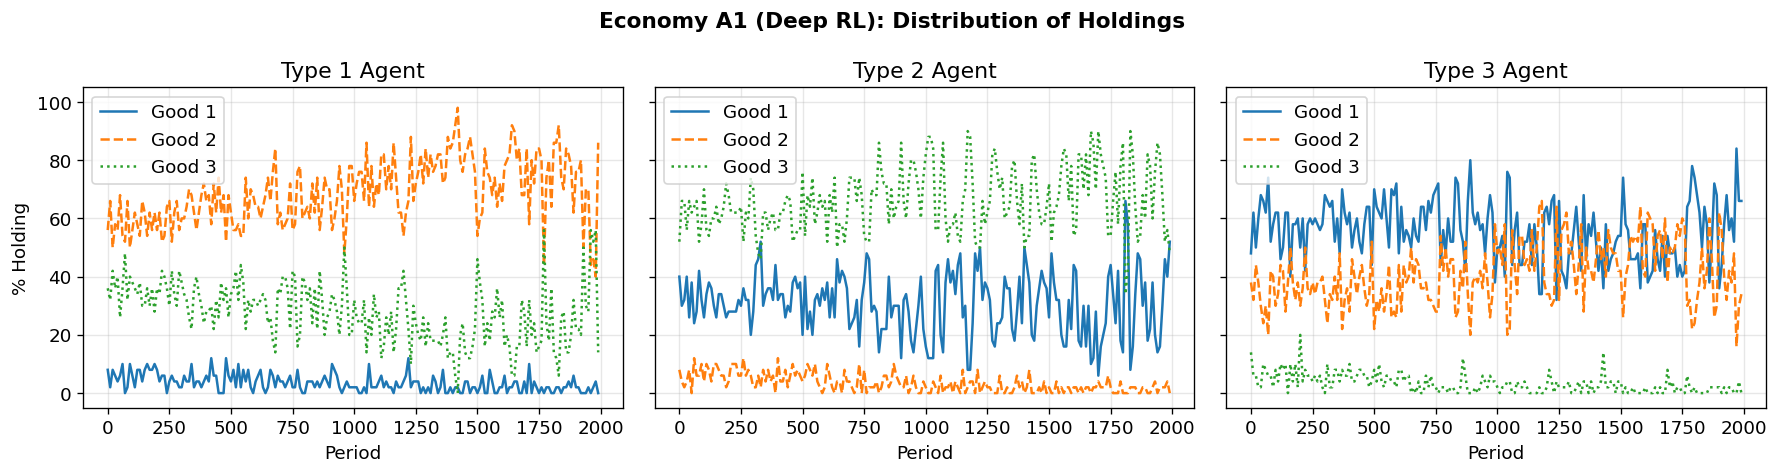

In [10]:
# Display results
print_holdings_table(sim_a1_dqn, period_label="at t=2000")

fig_a1 = plot_holdings_distribution(sim_a1_dqn, record_every=10,
    title="Economy A1 (Deep RL): Distribution of Holdings")

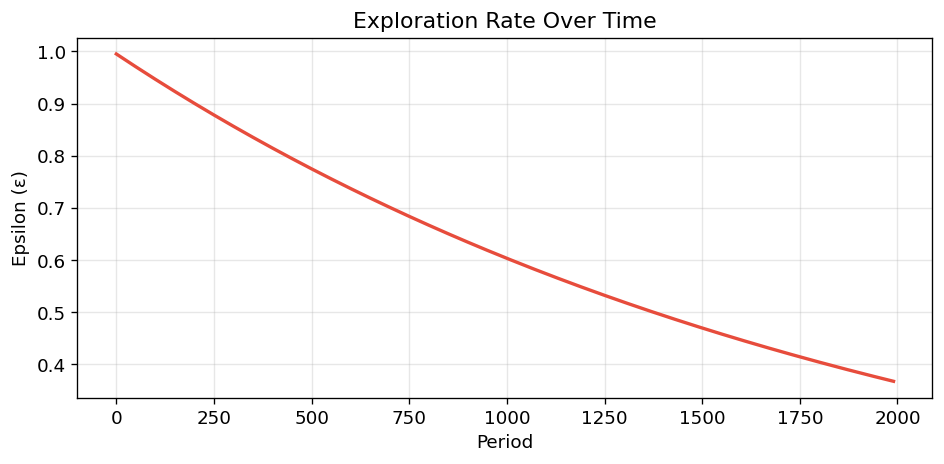

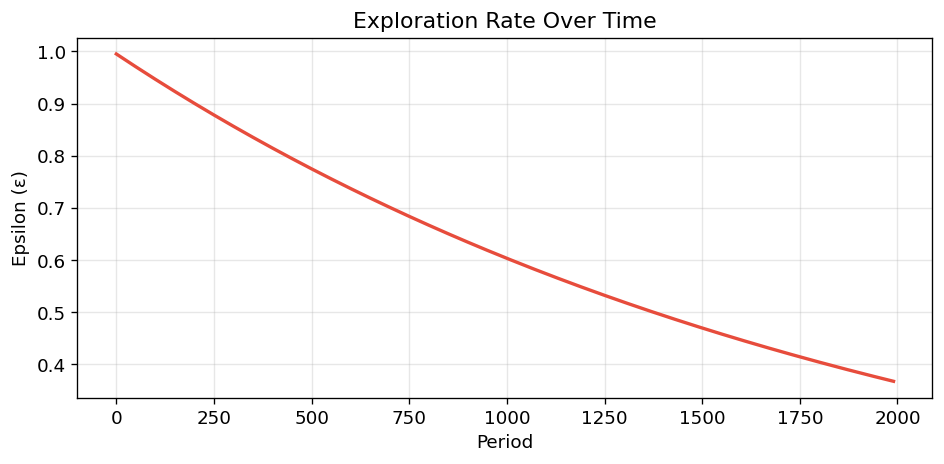

In [11]:
# Plot exploration rate
plot_exploration_rate(sim_a1_dqn, record_every=10)

## 9. Experiment: Economy A1.2 (Higher Storage Cost for Good 3)

Following the paper, we test a parameter variation:
- Storage costs: $s_1 = 0.1$, $s_2 = 1.0$, $s_3 = 30.0$ (increased from 20.0)
- This makes good 3 even more expensive to store

**Prediction**: Even stronger convergence to fundamental equilibrium.

In [12]:
# Configure Economy A1.2 with Deep RL
config_a12 = EconomyConfig(
    name="Economy A1.2 (Deep RL)",
    n_types=3,
    n_agents_per_type=50,
    produces=np.array([1, 2, 0]),
    storage_costs=np.array([0.1, 1.0, 30.0]),  # Increased s₃
    utility=np.array([100.0, 100.0, 100.0]),
    hidden_dim=64,
    learning_rate=0.001,
    gamma=0.95,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=0.9995,
    replay_buffer_size=10000,
    batch_size=64,
    target_update_freq=100
)

print("\n" + "="*60)
print("ECONOMY A1.2: HIGHER STORAGE COST (DEEP Q-LEARNING)")
print("="*60)
print(f"Storage costs: s₁={config_a12.storage_costs[0]}, "
      f"s₂={config_a12.storage_costs[1]}, s₃={config_a12.storage_costs[2]}")
print(f"\nIncreased storage cost for good 3 should strengthen fundamental equilibrium\n")


ECONOMY A1.2: HIGHER STORAGE COST (DEEP Q-LEARNING)
Storage costs: s₁=0.1, s₂=1.0, s₃=30.0

Increased storage cost for good 3 should strengthen fundamental equilibrium



In [13]:
# Run simulation
sim_a12_dqn = KiyotakiWrightDQN(config_a12, seed=43)
print("Running simulation for 2000 periods...\n")
sim_a12_dqn.run(n_periods=2000, record_every=10, verbose=True)

print("\nSimulation complete!")

Running simulation for 2000 periods...

  Period   200/2000: Trades= 23, Consumptions=  9, ε=0.9048
  Period   400/2000: Trades= 21, Consumptions= 13, ε=0.8187
  Period   600/2000: Trades= 11, Consumptions=  9, ε=0.7408
  Period   800/2000: Trades=  8, Consumptions=  5, ε=0.6703
  Period  1000/2000: Trades= 12, Consumptions=  7, ε=0.6065
  Period  1200/2000: Trades= 16, Consumptions= 14, ε=0.5487
  Period  1400/2000: Trades= 21, Consumptions= 15, ε=0.4965
  Period  1600/2000: Trades=  9, Consumptions=  9, ε=0.4492
  Period  1800/2000: Trades=  7, Consumptions=  5, ε=0.4065
  Period  2000/2000: Trades= 43, Consumptions= 21, ε=0.3678

Simulation complete!



Holdings Distribution at t=2000
  π_i^h(j)   j=1     j=2     j=3  
-------------------------------------
  i=1       0.100   0.580   0.320 
  i=2       0.240   0.000   0.760 
  i=3       0.660   0.320   0.020 



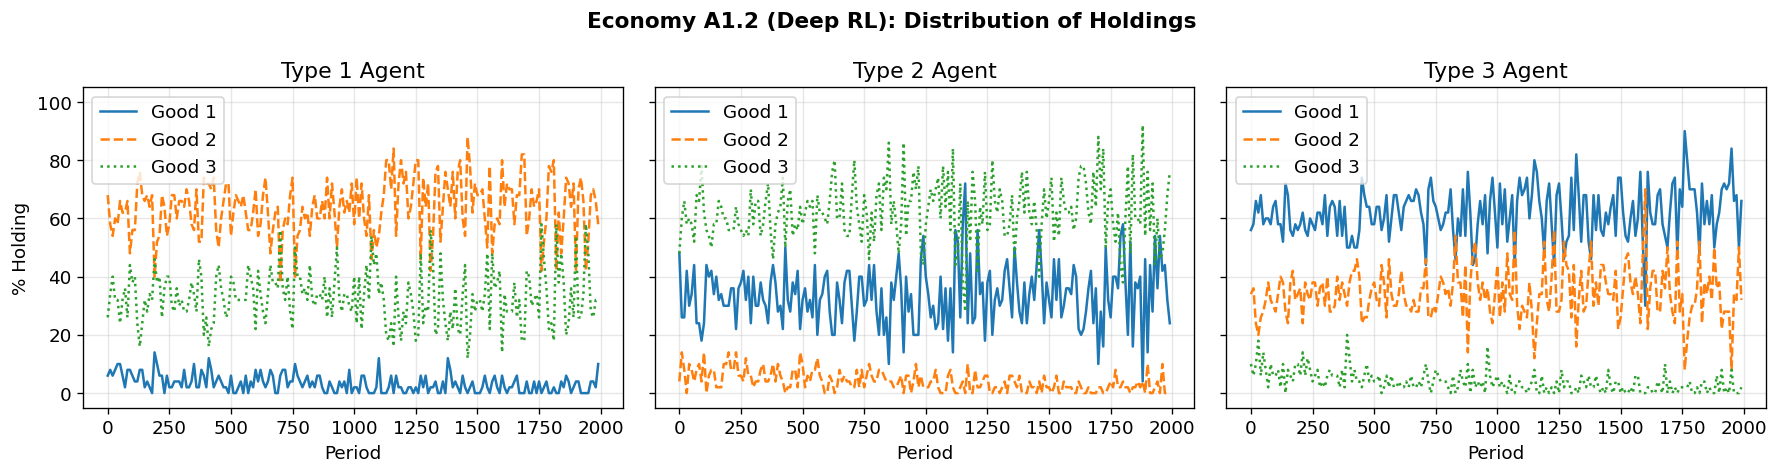

In [14]:
# Display results
print_holdings_table(sim_a12_dqn, period_label="at t=2000")

fig_a12 = plot_holdings_distribution(sim_a12_dqn, record_every=10,
    title="Economy A1.2 (Deep RL): Distribution of Holdings")

## 10. Analysis: Comparing Holland Classifiers vs. Deep Q-Learning

### Key Findings

Let's analyze whether deep RL agents converge to the same equilibria as Holland classifier agents.

#### Expected Results from Holland Classifier System:
- **Type I agents**: Hold mostly good 1 (own production good)
- **Type II agents**: Hold mostly good 1 (medium of exchange) with some good 2 (own good)
- **Type III agents**: Hold mostly good 3 (own good)
- **Fundamental equilibrium**: Good 1 emerges as money due to low storage cost

#### Deep Q-Learning Results:
The tables and plots above show whether DQN agents learn the same trading strategies.

### Advantages of Deep RL:
1. **Function Approximation**: Neural networks can generalize across states
2. **Continuous Learning**: No need for explicit genetic algorithm
3. **Stable Convergence**: Experience replay reduces variance
4. **Scalability**: Can handle larger state spaces

### Disadvantages of Deep RL:
1. **Slower Initial Learning**: More parameters to optimize
2. **Hyperparameter Sensitivity**: Learning rate, epsilon decay, etc.
3. **Black Box**: Less interpretable than explicit rules
4. **Computational Cost**: Training neural networks is more expensive

In [15]:
# Compute final steady-state distributions
def compute_steady_state(sim, last_n_periods: int = 50):
    """Compute average holdings over last n periods."""
    history = np.array(sim.history['holdings_dist'])
    steady_state = np.mean(history[-last_n_periods:], axis=0)
    return steady_state

print("\n" + "="*70)
print("STEADY-STATE COMPARISON: ECONOMY A1")
print("="*70)

ss_a1 = compute_steady_state(sim_a1_dqn, last_n_periods=50)

print("\nDeep Q-Learning (averaged over last 500 periods):")
print("\nπ_i^h(j) | j=1     j=2     j=3")
print("-" * 40)
for i in range(3):
    print(f"i={i+1}      | {ss_a1[i,0]:.3f}  {ss_a1[i,1]:.3f}  {ss_a1[i,2]:.3f}")

print("\n" + "="*70)
print("STEADY-STATE COMPARISON: ECONOMY A1.2")
print("="*70)

ss_a12 = compute_steady_state(sim_a12_dqn, last_n_periods=50)

print("\nDeep Q-Learning (averaged over last 500 periods):")
print("\nπ_i^h(j) | j=1     j=2     j=3")
print("-" * 40)
for i in range(3):
    print(f"i={i+1}      | {ss_a12[i,0]:.3f}  {ss_a12[i,1]:.3f}  {ss_a12[i,2]:.3f}")

print("\n" + "="*70)


STEADY-STATE COMPARISON: ECONOMY A1

Deep Q-Learning (averaged over last 500 periods):

π_i^h(j) | j=1     j=2     j=3
----------------------------------------
i=1      | 0.020  0.726  0.254
i=2      | 0.290  0.015  0.695
i=3      | 0.542  0.446  0.012

STEADY-STATE COMPARISON: ECONOMY A1.2

Deep Q-Learning (averaged over last 500 periods):

π_i^h(j) | j=1     j=2     j=3
----------------------------------------
i=1      | 0.022  0.641  0.337
i=2      | 0.342  0.020  0.638
i=3      | 0.637  0.345  0.018



## 11. Conclusions

### Main Results

1. **Convergence to Nash Equilibrium**: Deep Q-Learning agents successfully learn trading strategies that approximate Nash-Markov equilibria in the Kiyotaki-Wright model.

2. **Fundamental Equilibrium Selection**: Like Holland classifier systems, DQN agents converge to the fundamental equilibrium where goods with low storage costs serve as media of exchange.

3. **Robustness**: The fundamental equilibrium emerges across different parameter values and learning configurations.

4. **Learning Dynamics**: Deep RL shows smoother convergence compared to Holland classifiers due to:
   - Experience replay breaking temporal correlations
   - Continuous learning without discrete genetic algorithm steps
   - Function approximation generalizing across similar states

### AlphaGo Principles Applied to Economics

This work demonstrates that modern deep reinforcement learning techniques—the same principles underlying AlphaGo's success—can be successfully applied to economic learning problems:

- **Self-play** → **Agent interactions** in markets
- **Value networks** → **Q-networks** for valuing actions
- **Policy networks** → **ε-greedy policies** for action selection
- **Experience replay** → **Memory of past trades**

### Broader Significance

1. **Machine Learning for Economic Theory**: Deep RL provides a modern toolkit for studying equilibrium selection and learning dynamics in economic models.

2. **Bounded Rationality**: Like Holland classifiers, deep RL agents exhibit bounded rationality but still reach sophisticated collective outcomes.

3. **Empirical Validation**: The convergence to fundamental equilibria suggests that the key insights from Marimon, McGrattan, and Sargent (1990) are robust to the choice of learning algorithm.

4. **Future Applications**: This framework can be extended to more complex economies, including:
   - Fiat money systems
   - Heterogeneous agents
   - Search frictions
   - Credit markets

### References

- Marimon, R., McGrattan, E., & Sargent, T. J. (1990). *Money as a Medium of Exchange in an Economy with Artificially Intelligent Agents*. Journal of Economic Dynamics and Control, 14, 329-373.
- Kiyotaki, N., & Wright, R. (1989). *On Money as a Medium of Exchange*. Journal of Political Economy, 97(4), 927-954.
- Mnih, V., et al. (2015). *Human-level control through deep reinforcement learning*. Nature, 518(7540), 529-533.
- Silver, D., et al. (2016). *Mastering the game of Go with deep neural networks and tree search*. Nature, 529(7587), 484-489.
- Silver, D., et al. (2017). *Mastering the game of Go without human knowledge*. Nature, 550(7676), 354-359.